**Ridge Regression**

#### *Project: Stock Market Trend Prediction with Regularization*

**Problem Statement:**
- Build a regression model for stock price prediction while reducing overfitting. 

In [16]:
# Step No 1 : Import required libraries
# Import numerical library
import numpy as np 
# Import pandas library 
import pandas as pd 
# Import plotting library
import matplotlib.pyplot as plt
# Import Seaborn library
import seaborn as sns 
# Import train test split 
from sklearn.model_selection import train_test_split
# Import Ridge Regression model
from sklearn.linear_model import Ridge
# Import evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [17]:
# Step No 2 : Data Loading and Exploration
df = pd.read_csv("AAPL.csv")

In [18]:
# Step No 3 : Understanding the Data
# Display first five rows 
print(df.head())
# Display statistical summary 
print(df.describe())
# Display dataset information 
print(df.info())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600
               Open          High  ...     Adj Close        Volume
count  10468.000000  10468.000000  ...  10468.000000  1.046800e+04
mean      14.757987     14.921491  ...     14.130431  3.308489e+08
std       31.914174     32.289158  ...     31.637275  3.388418e+08
min        0.049665      0.049665  ...      0.038329  0.000000e+00
25%        0.283482      0.289286  ...      0.235462  1.237768e+08
50%        0.474107      0.482768  ...      0.392373  2.181592e+08
75%       14.953303     15.057143  ...     12.835269  4.105794e+08
max     

In [19]:
# Step No 4 : Data Cleaning and Preprocessing
# Check missing values 
print(df.isnull().sum())
# Check duplicate rows 
print(df.duplicated().sum())
# Remove duplicate rows 
df = df.drop_duplicates()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
0


In [20]:
# Step No 5 : Features and Target Splitting
# Define input features
X = df[["Open" , "High" , "Low" , "Volume"]]

# Define target variable 
y = df["Close"]

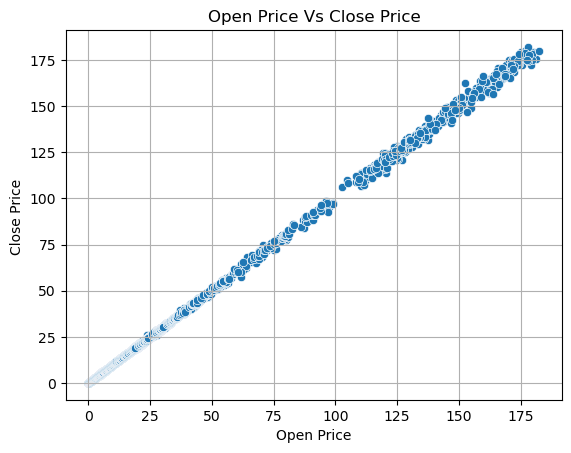

In [21]:
# Step No 6 : Visualization
sns.scatterplot(x="Open" , y="Close" , data=df)
#Set plot title
plt.title("Open Price Vs Close Price")
# Set x-axis label
plt.xlabel("Open Price")
# Set y-axis label
plt.ylabel("Close Price ")
# Enable grid 
plt.grid()
# Save images 
plt.savefig("images/Open Price Vs Close Price(Ridge Regression)")
# Display plot 
plt.show()

In [22]:
# Step No 7 : Train Test Split for Model Evaluation
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# Step No 8 : Initialize Ridge Regression Model
# Create Ridge Regression Model 
model = Ridge(alpha=1.0)
# alpha controls regularization strength


In [24]:
# Step No 9 : Model Training
model.fit(X_train , y_train)

c:\Users\sagar\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.87653e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [25]:
# Step No 10 : Prediction
# Predict stock prices 
y_pred = model.predict(X_test)
# Display predicted value 
print("Predicted Stock Prices : ")
print(y_pred)

Predicted Stock Prices : 
[11.40695575  0.32692036  0.35892418 ...  8.30551639  0.2072318
 24.50343538]


In [26]:
# Step No 11 : Model Evaluation
# Calculate MAE 
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Calculate MSE 
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

# Calculate R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
0.06625397942613756
Mean Squared Error : 
0.058525417912468396
Root Mean Squared Error : 
0.24192027180967782
R2 Score : 
0.9999372942323728


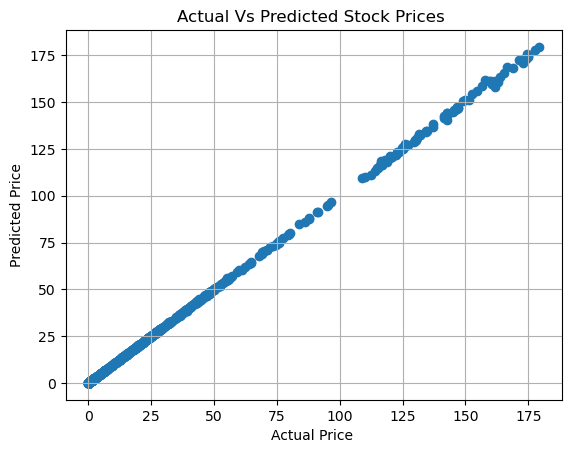

In [27]:
# Step No 12 : Actual vs Predicted Visualization
plt.scatter(y_test , y_pred)
# Set Plot title 
plt.title("Actual Vs Predicted Stock Prices ")
# Set x-axis label 
plt.xlabel("Actual Price ")
# Set y-axis label 
plt.ylabel("Predicted Price")
# Enable grid 
plt.grid()
# Save plot 
plt.savefig("images/Actual Vs Predicted Stock Prices(Ridge Regression).png")
# Show Plot 
plt.show() 

In [28]:
# Step No 13 : User Input
open_price = float(input("Enter Open Price : "))
high_price = float(input("Enter High Price : "))
low_price = float(input("Enter Low Price : "))
volume = float(input("Enter Volume : "))

In [29]:
# Step No 14 : Prediction on User Input
# Create user input dataframe 
user_data = pd.DataFrame({
    "Open": [open_price],
    "High": [high_price],
    "Low": [low_price],
    "Volume": [volume]
})

# Predict stock closing price 
result = model.predict(user_data)

In [30]:
# Step No 15 : Final Output
print(f"Predicted Closing Stock Price is : {result[0]:.2f}")

Predicted Closing Stock Price is : 331.30
